<a href="https://colab.research.google.com/github/prashikrangari/ETC-tech-C-/blob/main/Practical_no_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/RSS - Kriging.csv')

In [ ]:
df

,X,Y,RSS-A,RSS-B,RSS-C
0,0,2,49,73,69
1,0,3,50,70,70
2,0,4,50,68,70
3,0,5,51,68,71
4,0,6,52,67,70
...,...,...,...,...,...
198,6,26,62,65,51
199,6,27,61,65,51
200,6,28,60,65,51
201,6,29,61,65,51


In [ ]:
#Load Features and Targets
X = df[['X', 'Y']]
y = df[['RSS-A','RSS-B','RSS-C']]

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Train-Model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Prediction
y_pred=model.predict(X_test)

In [ ]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))
print(r2_score(y_test, y_pred))

2.9733908683654984
14.81743999709662
3.849342800673463
0.6866273567112615


In [ ]:
#Predict New location
new_location=[[4,3]]
pred=model.predict(new_location)
print(pred)

[[49.59393161 53.45567818 71.12458586]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#Actual vs Predicted
result=pd.DataFrame({'Actual RSS-A':y_test['RSS-A'].values,'Pred RSS-A':y_pred[:,0],'Actual RSS-B':y_test['RSS-B'].values,'Pred RSS-B':y_pred[:,1],'Actual RSS-C':y_test['RSS-C'].values,'Pred RSS-C':y_pred[:,2]})

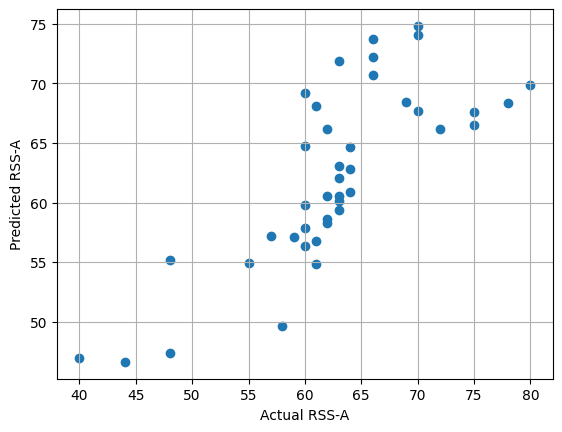

In [ ]:
#Plot RSS-A
plt.scatter(y_test['RSS-A'],y_pred[:,0])
plt.xlabel('Actual RSS-A')
plt.ylabel('Predicted RSS-A')
plt.grid(True)
plt.show()